<a href="https://colab.research.google.com/github/D2718281828nis/ML-MachineLearning-Graphs/blob/main/examples/graph_learning_basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/D2718281828nis/ML-MachineLearning-Graphs/blob/main/examples/graph_learning_basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Graph learning basics

**Goal.** Build, inspect, and visualize a small graph, then turn its structure into a feature matrix.

**Prerequisites.** Basic Python. **Runtime.** About 1 minute on a Colab CPU. **Output.** A graph plot and one normalized neighbor-aggregation step.

This example is intentionally self-contained and uses no external dataset.

## 1. Setup

In [1]:
%pip install -q networkx matplotlib numpy

import random
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

SEED = 37
random.seed(SEED)
np.random.seed(SEED)


## 2. Build a graph

Nodes are people and an edge represents a connection. NetworkX stores the topology; the `group` node attribute is a simple categorical feature.

In [2]:
edges = [
    ("Ada", "Ben"), ("Ada", "Chen"), ("Ben", "Chen"),
    ("Chen", "Dina"), ("Dina", "Eli"), ("Dina", "Fatima"),
    ("Eli", "Fatima"),
]
G = nx.Graph()
G.add_edges_from(edges)
nx.set_node_attributes(G, {
    "Ada": 0, "Ben": 0, "Chen": 0,
    "Dina": 1, "Eli": 1, "Fatima": 1,
}, "group")

print(f"nodes={G.number_of_nodes()}, edges={G.number_of_edges()}")
print("degrees:", dict(G.degree()))
assert nx.is_connected(G)


nodes=6, edges=7
degrees: {'Ada': 2, 'Ben': 2, 'Chen': 3, 'Dina': 3, 'Eli': 2, 'Fatima': 2}


## 3. Visualize

The spring layout is Euclidean and is used only for display. Fixed seeds keep the result reproducible.

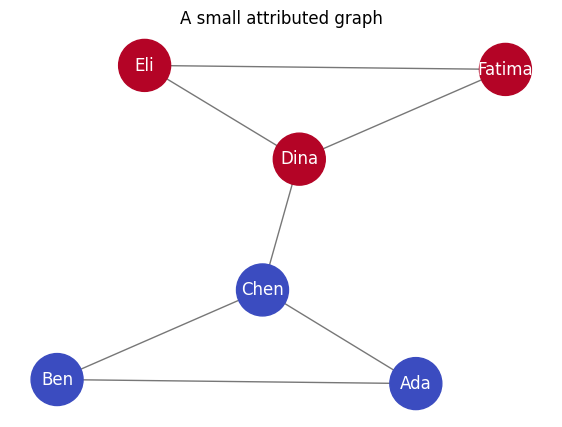

In [3]:
pos = nx.spring_layout(G, seed=SEED)
colors = [G.nodes[node]["group"] for node in G.nodes]
plt.figure(figsize=(7, 5))
nx.draw_networkx(G, pos, node_color=colors, cmap="coolwarm", node_size=1400,
                 font_color="white", edge_color="#777777")
plt.title("A small attributed graph")
plt.axis("off")
plt.show()


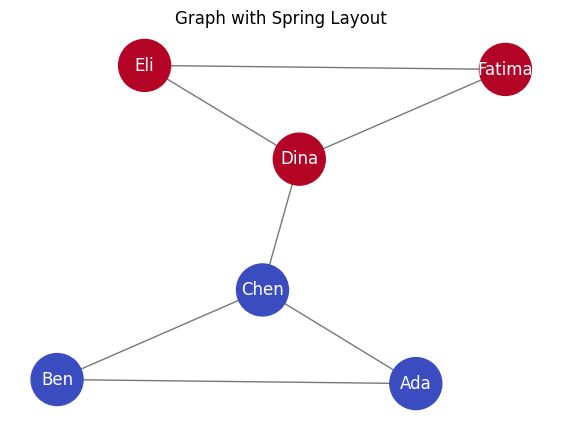

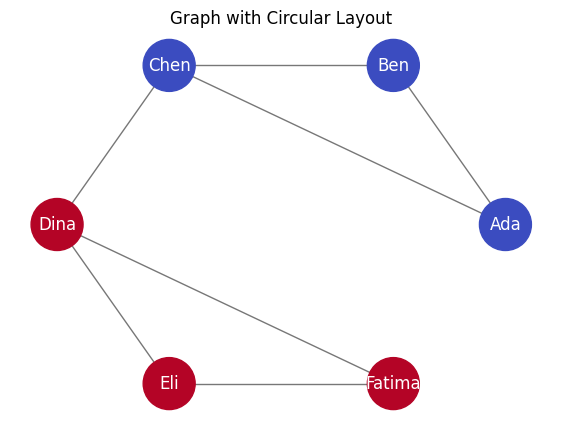

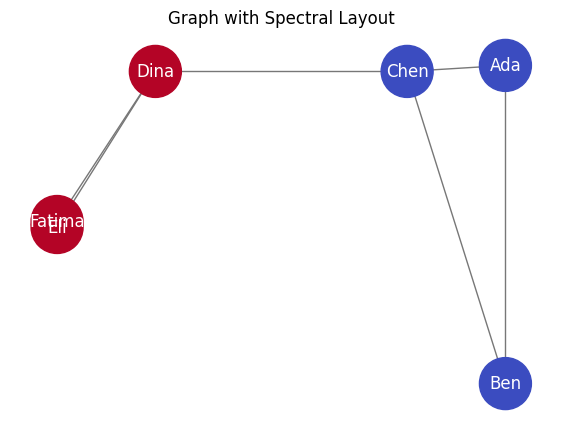

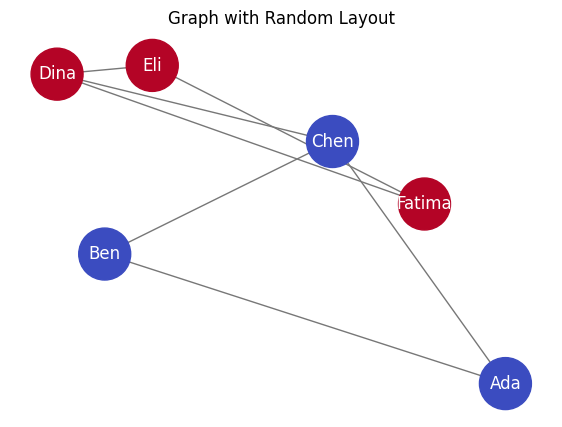

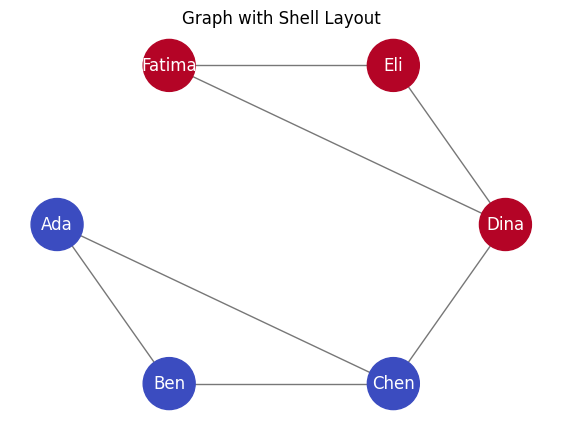

In [6]:
layouts = {
    "Spring Layout": nx.spring_layout,
    "Circular Layout": nx.circular_layout,
    "Spectral Layout": nx.spectral_layout,
    "Random Layout": nx.random_layout,
    "Shell Layout": nx.shell_layout,
}

for name, layout_func in layouts.items():
    plt.figure(figsize=(7, 5))
    if name == "Spring Layout":
        pos = layout_func(G, seed=SEED)
    else:
        pos = layout_func(G)
    nx.draw_networkx(G, pos, node_color=colors, cmap="coolwarm", node_size=1400,
                     font_color="white", edge_color="#777777")
    plt.title(f"Graph with {name}")
    plt.axis("off")
    plt.show()

## 4. One message-passing step

Let $A$ be the adjacency matrix and add self-loops: $\tilde A=A+I$. With
$\tilde D_{ii}=\sum_j\tilde A_{ij}$, a simple symmetric aggregation is

$$H'=\tilde D^{-1/2}\tilde A\tilde D^{-1/2}H.$$

Here $H$ is a one-hot group feature. This is the structural core used by a GCN layer, before learnable weights and an activation.

In [5]:
nodes = list(G.nodes)
A = nx.to_numpy_array(G, nodelist=nodes, dtype=float)
A_tilde = A + np.eye(len(nodes))
degree = A_tilde.sum(axis=1)
D_inv_sqrt = np.diag(degree ** -0.5)
propagation = D_inv_sqrt @ A_tilde @ D_inv_sqrt
H = np.eye(2)[[G.nodes[node]["group"] for node in nodes]]
H_next = propagation @ H

np.set_printoptions(precision=3, suppress=True)
print("node order:", nodes)
print("aggregated features:", H_next)
assert H_next.shape == (G.number_of_nodes(), 2)
assert np.isfinite(H_next).all()


node order: ['Ada', 'Ben', 'Chen', 'Dina', 'Eli', 'Fatima']
aggregated features: [[0.955 0.   ]
 [0.955 0.   ]
 [0.827 0.25 ]
 [0.25  0.827]
 [0.    0.955]
 [0.    0.955]]


## What next?

- Replace group IDs with real node features.
- Split edges or node labels into train/validation/test sets.
- Compare this Euclidean aggregation with the operations described in the [hyperbolic theory notes](../theory/hyperbolic-graphs/README.md).